# Tutorial Part 2 — Scikit-learn & Cross-Validation

This tutorial shows how to use `FairKernelRidge` with scikit-learn's
cross-validation and model selection tools.

**Outline**

1. Keras ↔ sklearn via `SKLearnRegressor`
2. A lightweight sklearn wrapper for `FairKernelRidge`
3. Cross-validation on hyperparameters (σ, λ)
4. Fairness-aware cross-validation (μ > 0)
5. Canonical plot — fairness vs accuracy (cross-validated)

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score

from fairkl.metrics.cka import cka_rbf
from fairkl.models import FairKernelRidge
from fairkl.sklearn_compat import FairKRREstimator
from _style import style_ax

## Same Synthetic Data as Part 1

In [2]:
rng = np.random.default_rng(0)
n = 200
x = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x, q]).astype("float32")
y = (np.sin(x.ravel()) + 3.0 * q.ravel() + 0.3 * rng.standard_normal(n)).astype(
    "float32"
)
print(
    f"n = {n},  d = {X.shape[1]},  corr(y, q) = {np.corrcoef(y, q.ravel())[0, 1]:.3f}"
)

n = 200,  d = 2,  corr(y, q) = 0.972


---
## 1  Keras ↔ sklearn: `SKLearnRegressor`

Keras 3 ships `keras.wrappers.SKLearnRegressor` which wraps a
**compiled** Keras model (i.e. one that uses `model.compile()` +
`model.fit(x, y, epochs=...)`) with sklearn's `get_params` /
`set_params` API.

`FairKernelRidge` uses a **custom solver** (Cholesky for μ=0, Adam for
μ>0) instead of the standard Keras training loop, so
`SKLearnRegressor` does not apply here.  Instead, we build a thin
sklearn-native wrapper.

---
## 2  The `FairKRREstimator` Wrapper

`fairkl.sklearn_compat.FairKRREstimator` wraps `FairKernelRidge`
with `sklearn.base.BaseEstimator` + `RegressorMixin`, giving us
`get_params()` / `set_params()` / `.score()` for free.

All constructor arguments are exposed as sklearn hyperparameters,
so `GridSearchCV` and `cross_val_score` work out of the box.

Quick sanity check:

In [3]:
est = FairKRREstimator(sigma=1.0, lam=0.01, mu=0.0)
print("get_params:", est.get_params())
est.fit(X, y)
print(f"R² = {est.score(X, y):.3f}")

get_params: {'epochs': 200, 'kernel': 'rbf', 'lam': 0.01, 'lr': 0.005, 'mu': 0.0, 'sigma': 1.0, 'sigma_q': 1.0}


R² = 0.992


---
## 3  Cross-Validation on Hyperparameters (μ=0)

With `mu=0` (standard KRR), we don't need the sensitive attribute.
`cross_val_score` works directly.

### 3.1  Bandwidth σ

In [4]:
sigmas = [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0]
cv_scores_sigma = []

for s in sigmas:
    est = FairKRREstimator(sigma=s, lam=0.01, mu=0.0)
    scores = cross_val_score(est, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores_sigma.append(-scores.mean())
    print(f"σ = {s:4.1f}   CV-MSE = {-scores.mean():.3f} ± {scores.std():.3f}")

σ =  0.1   CV-MSE = 6.789 ± 2.588
σ =  0.3   CV-MSE = 3.408 ± 2.494
σ =  0.5   CV-MSE = 2.555 ± 2.302
σ =  1.0   CV-MSE = 0.890 ± 1.159
σ =  2.0   CV-MSE = 0.181 ± 0.151
σ =  3.0   CV-MSE = 0.115 ± 0.042
σ =  5.0   CV-MSE = 0.141 ± 0.056


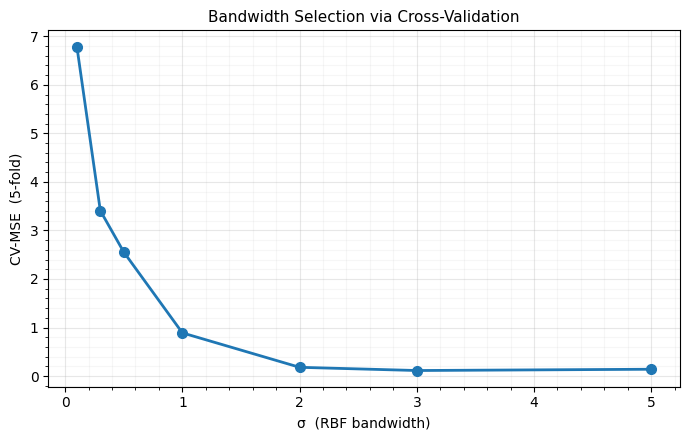

Best σ = 3.0


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sigmas, cv_scores_sigma, "o-", color="C0", lw=2, markersize=7)
ax.set_xlabel("σ  (RBF bandwidth)")
ax.set_ylabel("CV-MSE  (5-fold)")
ax.set_title("Bandwidth Selection via Cross-Validation", fontsize=11)
style_ax(ax)
plt.tight_layout()
plt.show()

best_sigma = sigmas[int(np.argmin(cv_scores_sigma))]
print(f"Best σ = {best_sigma}")

### 3.2  Ridge parameter λ

In [6]:
lams = [1e-4, 1e-3, 1e-2, 0.1, 1.0]
cv_scores_lam = []

for l in lams:
    est = FairKRREstimator(sigma=best_sigma, lam=l, mu=0.0)
    scores = cross_val_score(est, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores_lam.append(-scores.mean())
    print(f"λ = {l:.0e}   CV-MSE = {-scores.mean():.3f} ± {scores.std():.3f}")

λ = 1e-04   CV-MSE = 0.132 ± 0.066
λ = 1e-03   CV-MSE = 0.107 ± 0.041
λ = 1e-02   CV-MSE = 0.115 ± 0.042
λ = 1e-01   CV-MSE = 0.244 ± 0.210
λ = 1e+00   CV-MSE = 0.580 ± 0.537


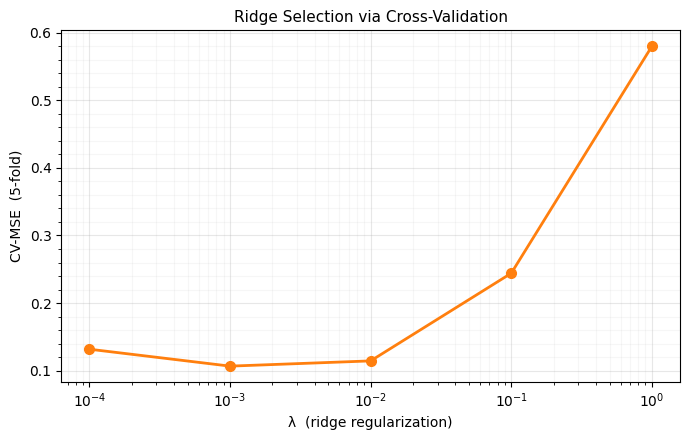

Best λ = 0.001


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogx(lams, cv_scores_lam, "o-", color="C1", lw=2, markersize=7)
ax.set_xlabel("λ  (ridge regularization)")
ax.set_ylabel("CV-MSE  (5-fold)")
ax.set_title("Ridge Selection via Cross-Validation", fontsize=11)
style_ax(ax)
plt.tight_layout()
plt.show()

best_lam = lams[int(np.argmin(cv_scores_lam))]
print(f"Best λ = {best_lam}")

---
## 4  Fairness-Aware Cross-Validation (μ > 0)

When `mu > 0`, we need the sensitive attribute `q` during training.
`cross_val_score` doesn't know about `q`, so we write a manual CV loop
using `sklearn.model_selection.KFold` that properly splits `X`, `y`,
**and** `q` together.

In [8]:
def fair_cv(X, y, q, mu, sigma, lam, sigma_q=1.0, epochs=200, lr=0.005, n_splits=5):
    """K-fold CV that returns both MSE and CKA on held-out folds."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mses, ckas = [], []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        q_tr, q_te = q[train_idx], q[test_idx]

        model = FairKernelRidge(sigma=sigma, lam=lam, mu=mu, sigma_q=sigma_q)
        model.fit(X_tr, y_tr, q=q_tr, epochs=epochs, lr=lr)
        yh = np.array(model.predict(X_te)).ravel()

        mses.append(float(np.mean((yh - y_te) ** 2)))
        ckas.append(float(cka_rbf(yh.reshape(-1, 1).astype("float32"), q_te)))

    return np.array(mses), np.array(ckas)

### 4.1  Sweep μ with cross-validation

In [9]:
mus = [0, 1, 5, 10, 20]
cv_mse_means, cv_mse_stds = [], []
cv_cka_means, cv_cka_stds = [], []

for mu in mus:
    mses, ckas = fair_cv(
        X, y, q, mu=mu, sigma=best_sigma, lam=best_lam, epochs=200, lr=0.005
    )
    cv_mse_means.append(mses.mean())
    cv_mse_stds.append(mses.std())
    cv_cka_means.append(ckas.mean())
    cv_cka_stds.append(ckas.std())
    print(
        f"μ = {mu:5.1f}   "
        f"CV-MSE = {mses.mean():.3f} ± {mses.std():.3f}   "
        f"CV-CKA = {ckas.mean():.3f} ± {ckas.std():.3f}"
    )

μ =   0.0   CV-MSE = 0.110 ± 0.010   CV-CKA = 0.674 ± 0.022


μ =   1.0   CV-MSE = 0.131 ± 0.015   CV-CKA = 0.635 ± 0.022


μ =   5.0   CV-MSE = 0.828 ± 0.086   CV-CKA = 0.416 ± 0.047


μ =  10.0   CV-MSE = 1.792 ± 0.274   CV-CKA = 0.293 ± 0.077


μ =  20.0   CV-MSE = 3.694 ± 0.488   CV-CKA = 0.176 ± 0.082


---
## 5  Canonical Plot — Fairness vs Accuracy (Cross-Validated)

The Pareto frontier now uses **held-out** metrics — a more honest
picture of the fairness-accuracy trade-off than training metrics.

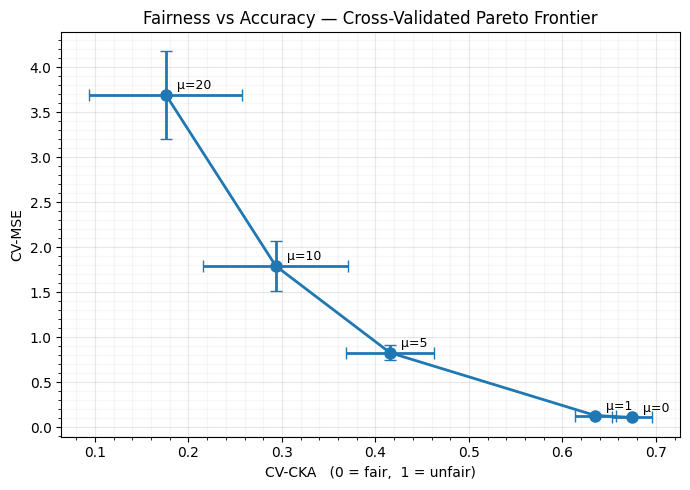

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    cv_cka_means,
    cv_mse_means,
    xerr=cv_cka_stds,
    yerr=cv_mse_stds,
    fmt="o-",
    color="C0",
    lw=2,
    markersize=8,
    capsize=4,
)
for i, mu in enumerate(mus):
    ax.annotate(
        f"μ={mu}",
        (cv_cka_means[i], cv_mse_means[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
    )
ax.set_xlabel("CV-CKA   (0 = fair,  1 = unfair)")
ax.set_ylabel("CV-MSE")
ax.set_title("Fairness vs Accuracy — Cross-Validated Pareto Frontier", fontsize=12)
style_ax(ax)
plt.tight_layout()
plt.show()

**Key takeaway**: the cross-validated Pareto frontier gives error bars,
showing how stable the fairness-accuracy trade-off is across folds.
This is more trustworthy than training-set metrics.

---

**Next**: [Part 3](tutorial_fair_krr_part3.py) explores the full
`fairkl` API and Keras integration (losses, metrics, kernel layers).